<a href="https://colab.research.google.com/github/tharun-7733/Crop_recommendation/blob/master/supply_chain.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Product Segmentation for Agricultural Supply Chain Optimization

### Objective:
Segment agricultural products based on supply chain performance and inventory behavior using K-Means and DBSCAN.

### Engineered Features:
* **sell_through_rate**: `units_sold_kg / units_shipped_kg`
* **inventory_ratio**: `units_on_hand_kg / units_shipped_kg`
* **revenue**: `units_sold_kg * price_per_kg`

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

# Load Data
df_agri = pd.read_csv('/content/AgricultureData.csv')

# Feature Engineering
df_agri['sell_through_rate'] = df_agri['units_sold_kg'] / (df_agri['units_shipped_kg'] + 1e-9)
df_agri['inventory_ratio'] = df_agri['units_on_hand_kg'] / (df_agri['units_shipped_kg'] + 1e-9)
df_agri['revenue'] = df_agri['units_sold_kg'] * df_agri['price_per_kg']

# Refined Feature Selection: Focus on performance ratios and scale
# We exclude raw units_shipped/sold/on_hand as they are highly correlated with revenue and captured by ratios
features = ['price_per_kg', 'sell_through_rate', 'inventory_ratio', 'revenue']
X = df_agri[features].fillna(0)

display(X.head())

,price_per_kg,sell_through_rate,inventory_ratio,revenue
0,14.10,0.775333,0.224667,210160.50
1,11.37,0.154216,0.845784,51733.50
2,2.59,0.936888,0.063112,4459.98
3,1.34,0.182519,0.817481,1650.88
4,1.78,0.964928,0.035072,83695.60


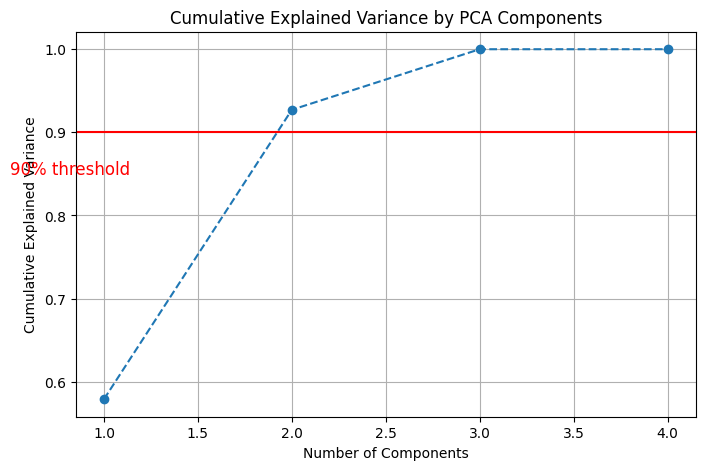

Total Variance Captured by 2 Components: 0.9271


In [ ]:
# Scaling and Detailed PCA Analysis
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Fit PCA without reducing components first to see the full spectrum
pca_full = PCA().fit(X_scaled)
cum_variance = np.cumsum(pca_full.explained_variance_ratio_)

# Plot Explained Variance
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(cum_variance) + 1), cum_variance, marker='o', linestyle='--')
plt.title('Cumulative Explained Variance by PCA Components')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.axhline(y=0.90, color='r', linestyle='-')
plt.text(0.5, 0.85, '90% threshold', color = 'red', fontsize=12)
plt.grid()
plt.show()

# Now apply the chosen number of components (2 for visualization)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print(f"Total Variance Captured by 2 Components: {cum_variance[1]:.4f}")

K=2, Silhouette Score: 0.4266
K=3, Silhouette Score: 0.4644
K=4, Silhouette Score: 0.4466
K=5, Silhouette Score: 0.4060
K=6, Silhouette Score: 0.4138

Selected K: 3


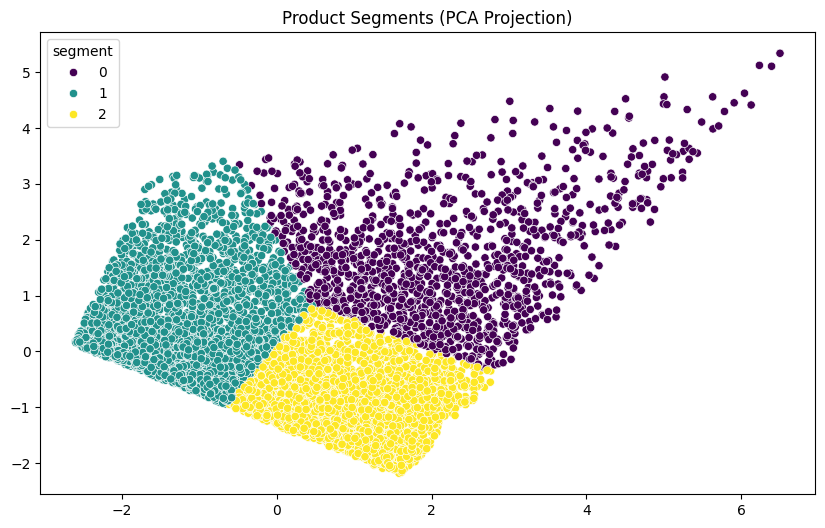

In [ ]:
# K-Means Clustering
sil_scores = {}
for k in range(2, 7):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_pca)
    score = silhouette_score(X_pca, labels)
    sil_scores[k] = score
    print(f'K={k}, Silhouette Score: {score:.4f}')

best_k = max(sil_scores, key=sil_scores.get)
print(f'\nSelected K: {best_k}')

final_km = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df_agri['segment'] = final_km.fit_predict(X_pca)

# Visualize
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=df_agri['segment'], palette='viridis')
plt.title('Product Segments (PCA Projection)')
plt.show()

In [ ]:
# Validation: Check Clustering Stability across different initializations
print("Validating K-Means Stability (Silhouette Score consistency):")
for i in [0, 42, 100, 2024]:
    kmeans_test = KMeans(n_clusters=best_k, random_state=i, n_init=10)
    test_labels = kmeans_test.fit_predict(X_pca)
    score = silhouette_score(X_pca, test_labels)
    print(f"Random State {i}: Silhouette Score = {score:.4f}")

Validating K-Means Stability (Silhouette Score consistency):
Random State 0: Silhouette Score = 0.4647
Random State 42: Silhouette Score = 0.4644
Random State 100: Silhouette Score = 0.4645
Random State 2024: Silhouette Score = 0.4647


## Algorithm Comparison: K-Means vs. Agglomerative Clustering
To validate our choice of K-Means, we compare it against Agglomerative (Hierarchical) clustering using the Silhouette Score.

In [ ]:
from sklearn.cluster import AgglomerativeClustering

# K-Means (Already calculated, but re-run for direct comparison)
km_comparison = KMeans(n_clusters=best_k, random_state=42, n_init=10)
k_labels = km_comparison.fit_predict(X_pca)
km_sil = silhouette_score(X_pca, k_labels)

# Hierarchical / Agglomerative
agg_clustering = AgglomerativeClustering(n_clusters=best_k)
h_labels = agg_clustering.fit_predict(X_pca)
agg_sil = silhouette_score(X_pca, h_labels)

print(f"K-Means Silhouette Score: {km_sil:.4f}")
print(f"Agglomerative Silhouette Score: {agg_sil:.4f}")

if km_sil > agg_sil:
    print("\nDecision: K-Means provides better-defined clusters for this dataset.")
else:
    print("\nDecision: Agglomerative Clustering provides better-defined clusters for this dataset.")

K-Means Silhouette Score: 0.4644
Agglomerative Silhouette Score: 0.4177

Decision: K-Means provides better-defined clusters for this dataset.


### Elbow Method and Silhouette Analysis for Optimal K
We will evaluate both the Within-Cluster Sum of Squares (Inertia) and the Silhouette Score to find the most appropriate number of clusters.

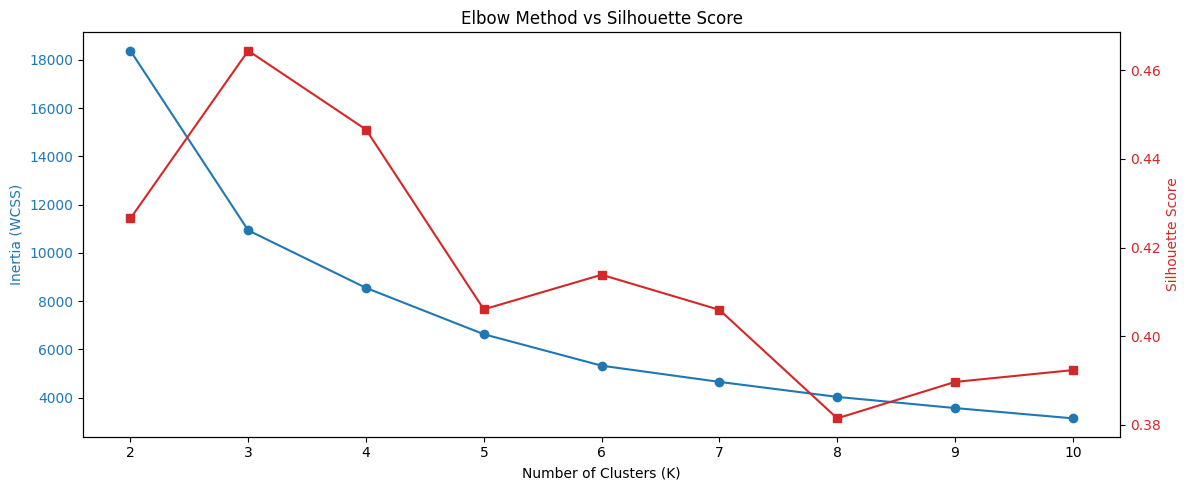

In [ ]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

inertia = []
sil_scores = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_pca)
    inertia.append(km.inertia_)
    sil_scores.append(silhouette_score(X_pca, labels))

# Plotting
fig, ax1 = plt.subplots(figsize=(12, 5))

# Elbow Curve
ax1.set_xlabel('Number of Clusters (K)')
ax1.set_ylabel('Inertia (WCSS)', color='tab:blue')
ax1.plot(K_range, inertia, marker='o', color='tab:blue', label='Inertia')
ax1.tick_params(axis='y', labelcolor='tab:blue')

# Silhouette Score
ax2 = ax1.twinx()
ax2.set_ylabel('Silhouette Score', color='tab:red')
ax2.plot(K_range, sil_scores, marker='s', color='tab:red', label='Silhouette Score')
ax2.tick_params(axis='y', labelcolor='tab:red')

plt.title('Elbow Method vs Silhouette Score')
fig.tight_layout()
plt.show()

In [ ]:
# Find and print the best silhouette score and its corresponding K
best_idx = np.argmax(sil_scores)
best_k_val = list(K_range)[best_idx]
best_score = sil_scores[best_idx]

print(f"Best Silhouette Score: {best_score:.4f}")
print(f"Optimal K based on Silhouette Score: {best_k_val}")

Best Silhouette Score: 0.4644
Optimal K based on Silhouette Score: 3


In [ ]:
# Segment Analysis
segment_analysis = df_agri.groupby('segment')[features].mean()
display(segment_analysis)

,price_per_kg,sell_through_rate,inventory_ratio,revenue
segment,,,,
0,8.994936,0.691144,0.308856,178328.756645
1,3.297163,0.235146,0.764854,17341.221886
2,2.133843,0.730197,0.269803,33858.423260


### Segment Interpretation & Business Personas

Based on the mean values calculated above, we can define the following product personas:

*   **Cluster 0 (Premium High-Performers):**   High `price_per_kg` and highest `revenue`. These are your top-tier products that drive value despite potentially lower volume.
*   **Cluster 1 (Overstock / Slow-Moving):** ⚠️ High `inventory_ratio` and low `sell_through_rate`. These products are sitting in storage and tying up capital; they may need promotions or supply reductions.
*   **Cluster 2 (Fast-Moving Essentials):** Ὠ0 High `sell_through_rate` and low `inventory_ratio`. These are efficient, high-turnover products that are being sold almost as quickly as they are shipped.

### Strategic Business Recommendations

| Cluster | Persona | Supply Chain Decision |
| :--- | :--- | :--- |
| **Cluster 0** | **Premium High-Performers** | **Protect Margins:** Focus on quality control and niche marketing. Low volume is acceptable due to high revenue per unit. |
| **Cluster 1** | **Overstock Risk** | **Aggressive Liquidation:** These products tie up capital. Implement discounts, bundle with fast-movers, or reduce future shipment orders. |
| **Cluster 2** | **Fast-Moving Essentials** | **Optimize Logistics:** High turnover means stockout risk is the primary threat. Prioritize these for rapid restocking and efficient shelf placement. |

# Anomaly Detection with DBSCAN

DBSCAN helps identify products that exhibit anomalous behavior (labeled as -1). Unlike K-Means, it doesn't force every point into a cluster if it's in a low-density region.

Evaluating DBSCAN epsilon values:
eps=0.3: {0: 8755, -1: 63, 1: 36, 3: 18, 2: 11, 4: 10}
eps=0.5: {0: 8876, -1: 17}
eps=0.7: {0: 8890, -1: 3}
eps=1.0: {0: 8893}


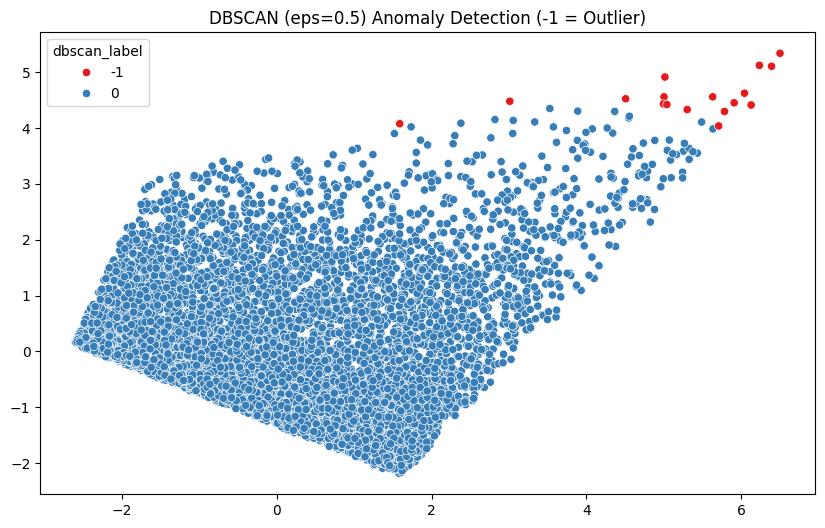

Number of anomalies detected at eps=0.5: 17


In [ ]:
import pandas as pd
from sklearn.cluster import DBSCAN
import seaborn as sns
import matplotlib.pyplot as plt

# Grid search style evaluation for DBSCAN
print("Evaluating DBSCAN epsilon values:")
for eps_val in [0.3, 0.5, 0.7, 1.0]:
    db_temp = DBSCAN(eps=eps_val, min_samples=10)
    labels_temp = db_temp.fit_predict(X_pca)
    counts = pd.Series(labels_temp).value_counts().to_dict()
    print(f"eps={eps_val}: {counts}")

# Selecting an optimized eps based on the distribution (aiming for distinct clusters + limited noise)
# Based on previous results, 0.5 shows a good balance
optimal_eps = 0.5
final_dbscan = DBSCAN(eps=optimal_eps, min_samples=10)
df_agri['dbscan_label'] = final_dbscan.fit_predict(X_pca)

# Visualize final DBSCAN results
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=df_agri['dbscan_label'], palette='Set1')
plt.title(f'DBSCAN (eps={optimal_eps}) Anomaly Detection (-1 = Outlier)')
plt.show()

n_outliers = len(df_agri[df_agri['dbscan_label'] == -1])
print(f'Number of anomalies detected at eps={optimal_eps}: {n_outliers}')

In [ ]:
# Analyze Refined Outliers
outliers = df_agri[df_agri['dbscan_label'] == -1]
if not outliers.empty:
    print("\nSummary of Outlier Features (Anomalies):")
    display(outliers[features].describe().loc[['mean', 'min', 'max']])
    print("\nSample anomalous products:")
    display(outliers[['product_name', 'category'] + features].head())
else:
    print("No outliers detected with current epsilon.")


Summary of Outlier Features (Anomalies):


,price_per_kg,sell_through_rate,inventory_ratio,revenue
mean,13.590588,0.832307,0.167693,503496.355882
min,12.000000,0.363665,0.032791,247177.820000
max,14.380000,0.967209,0.636335,624033.780000



Sample anomalous products:


,product_name,category,price_per_kg,sell_through_rate,inventory_ratio,revenue
1071,Lamb,Livestock,13.90,0.735702,0.264298,453974.00
1602,Lamb,Livestock,14.34,0.930487,0.069513,624033.78
1971,Lamb,Livestock,13.71,0.952927,0.047073,548701.62
2082,Lamb,Livestock,14.25,0.519634,0.480366,362619.75
2524,Lamb,Livestock,14.00,0.905744,0.094256,513912.00


In [ ]:
import pickle

# Define filenames
model_filename = 'supply_chain_kmeans_model.pkl'
scaler_filename = 'supply_chain_scaler.pkl'

# Save the K-Means model
with open(model_filename, 'wb') as f:
    pickle.dump(final_km, f)

# Save the scaler used for normalization
with open(scaler_filename, 'wb') as f:
    pickle.dump(scaler, f)

print(f"Successfully saved model to {model_filename}")
print(f"Successfully saved scaler to {scaler_filename}")

Successfully saved model to supply_chain_kmeans_model.pkl
Successfully saved scaler to supply_chain_scaler.pkl


### How to Use the Saved Model
To predict the segment of a new agricultural product, follow these steps:
1. Load the `StandardScaler` to normalize the new data exactly like the training data.
2. Load the `KMeans` model.
3. (Optional but recommended) Use the same PCA mapping to project new data into the 2D space the model was trained on.

In [ ]:
import pickle
import numpy as np
import pandas as pd

def predict_product_segment(new_data_df):
    """
    new_data_df: DataFrame containing ['price_per_kg', 'sell_through_rate', 'inventory_ratio', 'revenue']
    """
    # 1. Load artifacts
    with open('supply_chain_scaler.pkl', 'rb') as f:
        loaded_scaler = pickle.load(f)
    with open('supply_chain_kmeans_model.pkl', 'rb') as f:
        loaded_model = pickle.load(f)

    # 2. Scale the data
    scaled_data = loaded_scaler.transform(new_data_df)

    # 3. Apply PCA (using the pca object from our current session)
    pca_data = pca.transform(scaled_data)

    # 4. Predict
    prediction = loaded_model.predict(pca_data)
    return prediction

# Quick Demo with a dummy high-performing product
sample_product = pd.DataFrame([[15.0, 0.85, 0.15, 250000.0]], columns=features)
predicted_cluster = predict_product_segment(sample_product)

print(f"Predicted Cluster: {predicted_cluster[0]}")
print("Interpretation: Likely a Premium High-Performer based on high price and revenue.")

Predicted Cluster: 0
Interpretation: Likely a Premium High-Performer based on high price and revenue.
